# MNIST DCGAN with Native PyTorch

This complete workflow modernizes the archived DCGAN. A fixed 100-dimensional noise panel
tracks the same generated samples across training. Full execution uses 50
epochs and batch size 128. Reduce `EPOCHS` to 1 or 2 for a quicker run.

Losses and selected images are diagnostics, not proof that the generator
learned the complete data distribution.

## Runtime dependency check

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_RUNTIME = {'torch': 'torch'}
COLAB_EXTRAS = {}
missing_required = [
    package for module, package in REQUIRED_RUNTIME.items()
    if importlib.util.find_spec(module) is None
]
missing_extras = [
    package for module, package in COLAB_EXTRAS.items()
    if importlib.util.find_spec(module) is None
]
if missing_extras and "google.colab" in sys.modules:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_extras]
    )
    missing_extras = []
if missing_required or missing_extras:
    missing = ", ".join(missing_required + missing_extras)
    raise RuntimeError(
        f"Missing notebook dependencies: {missing}. Locally run "
        "`uv sync --group notebooks`; in Colab restart the runtime if an "
        "installation cell just changed the environment."
    )
print("runtime dependency check passed")

runtime dependency check passed


In [2]:
%matplotlib inline

## Imports, data, and fixed seeds

In [3]:
import hashlib
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets

print(f"PyTorch {torch.__version__}")

SEED = 42
EPOCHS = 50  # Reduce to 1 or 2 for a quicker run.
BATCH_SIZE = 128
LATENT_DIM = 100
LABEL_SMOOTHING = 0.0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
data_root = Path(os.getenv("HELIO_DATA_DIR", Path.home() / ".cache" / "helio-data-methods"))
mnist = datasets.MNIST(data_root, train=True, download=True)
x_train = (mnist.data.numpy().astype("float32") - 127.5) / 127.5
x_train = x_train[:, np.newaxis, ...]
loader = DataLoader(
    TensorDataset(torch.from_numpy(x_train)),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    generator=torch.Generator().manual_seed(SEED),
)
fixed_noise = torch.randn(16, LATENT_DIM, 1, 1, generator=torch.Generator().manual_seed(SEED))

PyTorch 2.13.0


## Define generator and discriminator

In [4]:
generator = nn.Sequential(
    nn.ConvTranspose2d(LATENT_DIM, 256, 7, 1, 0, bias=False),
    nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
    nn.ConvTranspose2d(256, 128, 5, 1, 2, bias=False),
    nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
    nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
    nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
    nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False), nn.Tanh(),
).to(DEVICE)
discriminator = nn.Sequential(
    nn.Conv2d(1, 64, 5, 2, 2), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Conv2d(64, 128, 5, 2, 2), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Flatten(), nn.Linear(128 * 7 * 7, 1),
).to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
generator_optimizer = torch.optim.Adam(generator.parameters(), lr=1e-4)
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

## Train adversarially

In [5]:
generator_losses, discriminator_losses = [], []
for epoch in range(EPOCHS):
    epoch_generator, epoch_discriminator = [], []
    for (real_images,) in loader:
        real_images = real_images.to(DEVICE)
        batch = len(real_images)
        noise = torch.randn(batch, LATENT_DIM, 1, 1, device=DEVICE)
        generated_images = generator(noise)

        discriminator_optimizer.zero_grad()
        real_logits = discriminator(real_images)
        generated_logits = discriminator(generated_images.detach())
        real_targets = torch.ones_like(real_logits) * (1.0 - LABEL_SMOOTHING)
        discriminator_loss = criterion(real_logits, real_targets) + criterion(
            generated_logits, torch.zeros_like(generated_logits)
        )
        discriminator_loss.backward()
        discriminator_optimizer.step()

        generator_optimizer.zero_grad()
        generated_logits = discriminator(generated_images)
        generator_loss = criterion(generated_logits, torch.ones_like(generated_logits))
        generator_loss.backward()
        generator_optimizer.step()
        epoch_generator.append(generator_loss.item())
        epoch_discriminator.append(discriminator_loss.item())
    generator_losses.append(float(np.mean(epoch_generator)))
    discriminator_losses.append(float(np.mean(epoch_discriminator)))
    print(
        f"epoch {epoch + 1}: generator={generator_losses[-1]:.4f}, "
        f"discriminator={discriminator_losses[-1]:.4f}"
    )

epoch 1: generator=1.7021, discriminator=0.7774


epoch 2: generator=1.1067, discriminator=1.1984


epoch 3: generator=1.0303, discriminator=1.2096


epoch 4: generator=1.0771, discriminator=1.1968


epoch 5: generator=1.1113, discriminator=1.1481


...

epoch 46: generator=0.8468, discriminator=1.2970


epoch 47: generator=0.8364, discriminator=1.3067


epoch 48: generator=0.8342, discriminator=1.3034


epoch 49: generator=0.8361, discriminator=1.3065


epoch 50: generator=0.8324, discriminator=1.3085


## Fixed-noise evidence

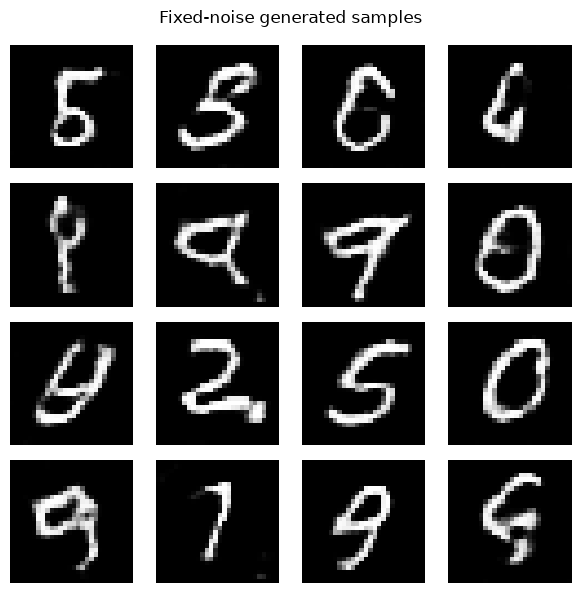

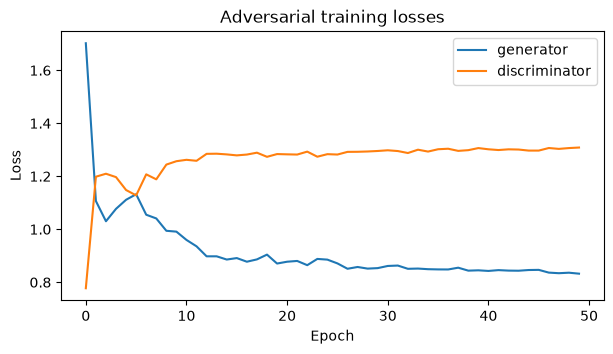

mean per-pixel sample standard deviation: 0.2926
HELIO_RESULT {"discriminator_loss": 1.3084635383043535, "epochs": 50, "generated_shape": [16, 28, 28, 1], "generator_loss": 0.8324452183949642, "pixel_diversity": 0.29259753227233887}


In [6]:
generator.eval()
with torch.no_grad():
    generated = generator(fixed_noise.to(DEVICE)).cpu().numpy()
generated = np.transpose(generated, (0, 2, 3, 1))

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for axis, image in zip(axes.flat, generated):
    axis.imshow(image.squeeze(), cmap="gray", vmin=-1, vmax=1)
    axis.axis("off")
plt.suptitle("Fixed-noise generated samples")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(generator_losses, label="generator")
ax.plot(discriminator_losses, label="discriminator")
ax.set(title="Adversarial training losses", xlabel="Epoch", ylabel="Loss")
ax.legend()
plt.show()

pixel_diversity = float(generated.std(axis=0).mean())
print(f"mean per-pixel sample standard deviation: {pixel_diversity:.4f}")
print(
    "HELIO_RESULT "
    + json.dumps(
        {
            "epochs": EPOCHS,
            "generated_shape": list(generated.shape),
            "generator_loss": generator_losses[-1],
            "discriminator_loss": discriminator_losses[-1],
            "pixel_diversity": pixel_diversity,
        },
        sort_keys=True,
    )
)
assert generated.shape == (16, 28, 28, 1)
assert np.isfinite(generated).all()
assert pixel_diversity > 0

## Try it yourself

Change one choice at a time and keep the data split and evaluation unchanged:

- try discriminator label smoothing of `0.1`.
- vary the latent dimension while keeping the fixed noise samples.
- save the fixed-noise grid at several points during training.